# Administration-Specific Modeling
To better understand how deportation outcomes vary across political contexts, we split the dataset into subsets corresponding to the Obama and Trump administrations. 

We then repeated the full modeling pipeline for each subset, allowing us to:
- Compare predictive performance across administrations
- Identify whether key predictors behave differently
- Analyze fairness disparities within each administration separately

### Repeating Steps from Base Model
---
We removed columns that could introduce data leakage, such as outcome-related dates and release reasons, since these variables would not be available at prediction time.

We then created additional features to better capture individual history and context:
- is_repeat_detention: whether the individual has been detained multiple times
- has_prior_removal: whether the individual has a prior removal history
- has_prior_arrest: whether the individual has multiple prior arrests

We also grouped continuous variables into categories:
- age_group: categorizes individuals into life stages (e.g., Young Adult, Adult)
- detention_bucket: groups detention duration into meaningful time ranges

These transformations improve model interpretability and allow categorical modeling techniques to capture patterns more effectively.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# Fairness
from sklearn.utils.class_weight import compute_sample_weight

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

BLUE    = "#1A237E"
PINK    = "#C2185B"
LIGHT   = "#F06292"
PALETTE = [BLUE, PINK, LIGHT, "#880E4F"]

In [2]:
df = pd.read_csv("../data/ICE_Master_Cleaned.csv", low_memory=False)
df.head()

,Stay Book In Date,Detention Book In Date,Detention Facility,Detention Book Out Date,Detention Release Reason,Stay Book Out Date,Stay Release Reason,Marital,Gender,Ethnicity,...,is_custodial_arrest,is_border_arrest,is_hispanic,is_male,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,State
0,2014-01-21,2014-01-21,Abilene Hold Room,2014-01-21,Voluntary Return,2014-01-21,Voluntary Return,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
1,2014-01-22,2014-01-22,Abilene Hold Room,2014-01-22,Order Of Recognizance,2014-01-22,Order Of Recognizance,Single,Male,Hispanic Origin,...,0,0,1,1,1,0,0,0,0,NaN
2,2014-10-06,2014-10-06,Abilene Hold Room,2014-10-06,Order Of Recognizance,2014-10-06,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
3,2014-09-15,2014-09-15,Abilene Hold Room,2014-09-15,Order Of Recognizance,2014-09-15,Order Of Recognizance,Single,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN
4,2014-10-31,2014-10-31,Abilene Hold Room,2014-10-31,Transferred,2014-11-06,Bonded Out,Married,Male,Unknown,...,0,0,0,1,1,0,0,0,0,NaN


In [3]:
# ── Feature Engineering ────────────────────────────────────────────────────
LEAKY_COLS = [
    'Final Order Date', 'Departed Date', 'days_to_removal', 'Departure Country',
    'Stay Book Out Date', 'Stay Book In Date', 'Detention Book In Date',
    'Detention Book Out Date', 'Stay Release Reason', 'Detention Release Reason',
    'removals_Processing Disposition', 'State', 'Detention Facility',
]

leaky_present = [c for c in LEAKY_COLS if c in df.columns]
model_df = df.drop(columns=leaky_present).copy()

model_df['is_repeat_detention'] = (model_df['running_detention_count'] > 1).astype(int)
model_df['has_prior_removal']   = (model_df['running_removal_count'] > 0).astype(int)
model_df['has_prior_arrest']    = (model_df['running_arrest_count'] > 1).astype(int)

def age_group(age):
    if pd.isna(age):    return 'Unknown'
    elif age < 18:      return 'Juvenile'
    elif age < 26:      return 'Young Adult'
    elif age < 40:      return 'Adult'
    elif age < 56:      return 'Middle Aged'
    else:               return 'Senior'

def detention_bucket(days):
    if pd.isna(days):   return 'Unknown'
    elif days == 0:     return 'Same Day'
    elif days <= 7:     return '1 Week'
    elif days <= 30:    return '1 Month'
    elif days <= 90:    return '3 Months'
    else:               return 'Long Term'

model_df['age_group']        = model_df['age_at_detention'].apply(age_group)
model_df['detention_bucket'] = model_df['detention_duration_days'].apply(detention_bucket)

print(f"Model dataframe shape: {model_df.shape}")
missing = model_df.isna().sum()
print("\nMissing values:"); print(missing[missing > 0].sort_values(ascending=False))

Model dataframe shape: (749491, 39)

Missing values:
detention_duration_days    14976
age_at_detention             498
dtype: int64


### Creating Administration Subsets
---
Split the data into two distinct datasets, one for the **Obama administration** and one for the **Trump administration**, to allow for a comparative analysis of policy impacts.

In [4]:
cols_to_export = model_df.columns.tolist()

for admin in ['Obama', 'Trump', 'Biden']:
    subset = model_df[model_df['administration'] == admin][cols_to_export]
    print(f"--- Head of {admin} subset ({len(subset)} rows) ---")
    display(subset.head())
    # subset.to_csv(f"ICE_{admin}_subset_modeling.csv", index=False)
    # print(f"Saved ICE_{admin}_subset_modeling.csv\n")

--- Head of Obama subset (247555 rows) ---


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
0,Single,Male,Hispanic Origin,1977.0,Pwa Mexico,Active,[9] Vr Under Safeguards,3.0,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
1,Single,Male,Hispanic Origin,1985.0,Pwa Mexico,Active,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
2,Single,Male,Unknown,1989.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Young Adult,Same Day
3,Single,Male,Unknown,1977.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,Same Day
4,Married,Male,Unknown,1969.0,Pwa Mexico,3-Voluntary Departure Confirmed,[8C] Excludable / Inadmissible - Administrativ...,2.0,0.0,0,...,1,0,0,0,0,0,0,0,Middle Aged,Same Day


--- Head of Trump subset (302241 rows) ---


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
12,Single,Male,Unknown,2011.0,Pwa Mexico,Active,[8B] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,0,...,1,0,0,0,1,0,0,0,Juvenile,Same Day
13,Single,Male,Hispanic Origin,2001.0,Unknown,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,0,0,0,0,1,0,1,0,Juvenile,Long Term
16,Single,Male,Unknown,1998.0,Unknown,Active,[8D] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Adult,Unknown
22,Unknown,Male,Hispanic Origin,1956.0,Not Applicable,Active,[1A] Voluntary Departure - Un-Expired And Un-E...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Senior,1 Month
31,Single,Male,Unknown,1983.0,Immigrant,Active,[16] Reinstated Final Order,3.0,0.0,0,...,0,0,0,0,0,0,0,0,Middle Aged,1 Week


--- Head of Biden subset (199695 rows) ---


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
17,Single,Male,Unknown,1986.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
18,Unknown,Male,Unknown,1992.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
19,Single,Male,Unknown,1993.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
20,Unknown,Male,Unknown,1991.0,Pwa Mexico,Active,"B(6), B(7)C",Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months
21,Unknown,Male,Unknown,1987.0,Pwa Mexico,Active,[8B] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,3 Months


### Modeling
---

In [5]:
obama_df = pd.read_csv("../data/ICE_Obama_subset_modeling.csv")
print(f"Obama subset shape: {obama_df.shape}")
obama_df.head()

Obama subset shape: (247555, 39)


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
0,Single,Male,Hispanic Origin,1977.0,Pwa Mexico,Active,[9] Vr Under Safeguards,3.0,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
1,Single,Male,Hispanic Origin,1985.0,Pwa Mexico,Active,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,1,0,0,0,0,0,0,0,Adult,Same Day
2,Single,Male,Unknown,1989.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Young Adult,Same Day
3,Single,Male,Unknown,1977.0,Pwa Mexico,Active,[8A] Excludable / Inadmissible - Hearing Not C...,Unknown,0.0,0,...,1,0,0,0,0,0,0,0,Adult,Same Day
4,Married,Male,Unknown,1969.0,Pwa Mexico,3-Voluntary Departure Confirmed,[8C] Excludable / Inadmissible - Administrativ...,2.0,0.0,0,...,1,0,0,0,0,0,0,0,Middle Aged,Same Day


In [6]:
trump_df = pd.read_csv("../data/ICE_Trump_subset_modeling.csv")
print(f"Trump subset shape: {trump_df.shape}")
trump_df.head()

Trump subset shape: (302241, 39)


,Marital,Gender,Ethnicity,Birth Year,Entry Status,Case Status,Case Category,Case Threat Level,days_to_stay,running_arrest_count,...,is_PWA,is_asylum_seeker,has_criminal_charge,is_convicted,is_juvenile,is_repeat_detention,has_prior_removal,has_prior_arrest,age_group,detention_bucket
0,Single,Male,Unknown,2011.0,Pwa Mexico,Active,[8B] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,0,...,1,0,0,0,1,0,0,0,Juvenile,Same Day
1,Single,Male,Hispanic Origin,2001.0,Unknown,8-Excluded/Removed - Inadmissibility,[8C] Excludable / Inadmissible - Administrativ...,Unknown,0.0,1,...,0,0,0,0,1,0,1,0,Juvenile,Long Term
2,Single,Male,Unknown,1998.0,Unknown,Active,[8D] Excludable / Inadmissible - Under Adjudic...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Adult,Unknown
3,Unknown,Male,Hispanic Origin,1956.0,Not Applicable,Active,[1A] Voluntary Departure - Un-Expired And Un-E...,Unknown,0.0,1,...,0,0,0,0,0,0,0,0,Senior,1 Month
4,Single,Male,Unknown,1983.0,Immigrant,Active,[16] Reinstated Final Order,3.0,0.0,0,...,0,0,0,0,0,0,0,0,Middle Aged,1 Week


In [7]:
# ── Feature sets (shared across both administration models) ─────────────────
TARGET = 'final_order_numeric'

BINARY_FEATURES = [
    'is_CAP_arrest', 'is_287g_arrest', 'is_custodial_arrest', 'is_border_arrest',
    'is_hispanic', 'is_male', 'is_PWA', 'is_asylum_seeker',
    'has_criminal_charge', 'is_convicted', 'is_juvenile',
    'is_repeat_detention', 'has_prior_removal', 'has_prior_arrest',
]
BINARY_FEATURES = [f for f in BINARY_FEATURES if f in model_df.columns]

NUMERIC_FEATURES = [
    'age_at_detention', 'detention_duration_days',
    'running_arrest_count', 'running_detention_count',
    'running_removal_count', 'year',
]
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in model_df.columns]

CATEGORICAL_FEATURES = [
    'Case Category', 'Case Status', 'Case Threat Level', 'Entry Status',
    'Gender', 'Ethnicity', 'Marital',
    'arrests_Apprehension Method',
    'removals_MSC Charge', 'removals_MSC Criminal Charge Status',
    'removals_Current Program', 'removals_Birth Country',
    'removals_Citizenship Country',
    'age_group', 'detention_bucket',
]

ALL_FEATURES = BINARY_FEATURES + NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Binary features  : {len(BINARY_FEATURES)}")
print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Categorical feats: {len(CATEGORICAL_FEATURES)}")
print(f"Total features   : {len(ALL_FEATURES)}")

Binary features  : 14
Numeric features : 6
Categorical feats: 15
Total features   : 35


### Shared Modeling Functions & Approach
---
#### Data Splitting
For each administration, we split the data into training (80%) and testing (20%) sets using stratified sampling Stratification ensures that the class distribution (Final Order vs. not) is preserved in both sets. We also computed sample weights to address class imbalance, ensuring that minority outcomes are properly represented during training.

#### Modeling Approach
We trained three classification models:
- Logistic Regression (baseline linear model)
- Decision Tree (interpretable non-linear model)
- Random Forest (ensemble model for improved performance)

All models were implemented using a unified pipeline that includes:
- Imputation for missing values
- Standardization for numeric features
- One-hot encoding for categorical variables

This ensures consistent preprocessing across models and prevents data leakage.

In [8]:
def build_pipeline(clf, binary_features, numeric_features, categorical_features):
    """
    Builds a full sklearn Pipeline with ColumnTransformer preprocessing:
      - Binary : passthrough (already 0/1)
      - Numeric: median imputation → StandardScaler
      - Categorical: constant imputation → OneHotEncoder
    """
    # Filter to only columns that exist in data (safety check)
    binary_present      = [f for f in binary_features      if f in obama_df.columns]
    numeric_present     = [f for f in numeric_features     if f in obama_df.columns]
    categorical_present = [f for f in categorical_features if f in obama_df.columns]

    preprocessor = ColumnTransformer(transformers=[
        ('binary', 'passthrough', binary_present),
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler()),
        ]), numeric_present),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categorical_present),
    ], remainder='drop')

    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   clf),
    ])


def evaluate_model(pipeline, X_test, y_test, model_name, admin_name):
    """Prints classification report and returns a summary dict."""
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    ap   = average_precision_score(y_test, y_prob) if y_prob is not None else np.nan

    print(f"\n{'='*55}")
    print(f"  {admin_name} | {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1       : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Avg Prec : {ap:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {'administration': admin_name, 'model': model_name,
            'accuracy': acc, 'f1': f1, 'roc_auc': auc, 'avg_precision': ap}


def plot_confusion_matrix(pipeline, X_test, y_test, model_name, admin_name, color):
    """Plots a styled confusion matrix."""
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test,
        colorbar=False, cmap=plt.cm.Blues, ax=ax
    )
    ax.set_title(f"{admin_name} — {model_name}\nConfusion Matrix")
    plt.tight_layout()
    plt.show()


def plot_roc_curves(pipelines_dict, X_test, y_test, admin_name):
    """Overlays ROC curves for all models on a single plot."""
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = PALETTE[:len(pipelines_dict)]

    for (name, pipeline), color in zip(pipelines_dict.items(), colors):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
           title=f"{admin_name} — ROC Curves")
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


def get_feature_importances(pipeline, top_n=20):
    clf = pipeline.named_steps['classifier']
    if not hasattr(clf, 'feature_importances_'):
        return None

    ct = pipeline.named_steps['preprocessor']

    # THIS is the key fix
    feature_names = ct.get_feature_names_out()

    importances = pd.Series(clf.feature_importances_, index=feature_names)
    return importances.nlargest(top_n)

def plot_feature_importances(importances, model_name, admin_name, color):
    """Horizontal bar chart of top feature importances."""
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(f"{admin_name} — {model_name}\nTop Feature Importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    feat_imp_df = importances.reset_index()
    feat_imp_df.columns = ['Feature', 'Importance']

    print("\nTop 10 features:")
    print(feat_imp_df.sort_values('Importance', ascending=False)
          .head(10)
          .to_string(index=False))

In [9]:
# Fairness Utility Functions

def compute_fairness_metrics(y_true, y_pred, group_mask, group_name):
    """
    Computes group-level fairness metrics for a binary sensitive attribute.

    Returns a dict with:
      - Positive Prediction Rate (PPR)  → Demographic Parity
      - True Positive Rate (TPR)        → Equal Opportunity
      - False Positive Rate (FPR)       → Predictive Equality
      - False Negative Rate (FNR)
      - Precision
    """
    results = {}
    for label, mask in [('group_1', group_mask), ('group_0', ~group_mask)]:
        yt = y_true[mask]
        yp = y_pred[mask]
        if len(yt) == 0:
            continue
        tp = ((yt == 1) & (yp == 1)).sum()
        fp = ((yt == 0) & (yp == 1)).sum()
        tn = ((yt == 0) & (yp == 0)).sum()
        fn = ((yt == 1) & (yp == 0)).sum()

        results[label] = {
            'n':         len(yt),
            'PPR':       yp.mean(),                          # P(ŷ=1)
            'TPR':       tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            'FPR':       fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            'FNR':       fn / (tp + fn) if (tp + fn) > 0 else np.nan,
            'Precision': tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        }
    return results


def fairness_report(pipeline, X_test, y_test, sensitive_cols, admin_name, model_name):
    """
    Runs fairness analysis over multiple sensitive attributes and returns
    a tidy DataFrame with disparity gaps for each group / metric.

    sensitive_cols: dict  {display_label: column_name_in_X_test}
                    e.g. {'Hispanic': 'is_hispanic', 'Male': 'is_male'}
    """
    y_pred = pipeline.predict(X_test)
    X_reset = X_test.reset_index(drop=True)
    y_reset = y_test.reset_index(drop=True)
    y_pred_s = pd.Series(y_pred)

    records = []
    for label, col in sensitive_cols.items():
        if col not in X_reset.columns:
            print(f"  [skip] '{col}' not in test set")
            continue
        group_mask = X_reset[col].astype(bool)
        metrics = compute_fairness_metrics(y_reset, y_pred_s, group_mask, label)

        for metric in ['PPR', 'TPR', 'FPR', 'FNR', 'Precision']:
            g1  = metrics.get('group_1', {}).get(metric, np.nan)
            g0  = metrics.get('group_0', {}).get(metric, np.nan)
            gap = g1 - g0
            records.append({
                'administration': admin_name,
                'model':          model_name,
                'attribute':      label,
                'metric':         metric,
                f'{label}=1':     round(g1,  4),
                f'{label}=0':     round(g0,  4),
                'gap (1 - 0)':    round(gap, 4),
            })

    return pd.DataFrame(records)


def plot_fairness_gaps(fairness_df, admin_name, model_name, color):
    """Bar chart of fairness disparity gaps across attributes and metrics."""
    df_plot = fairness_df.copy()
    df_plot['label'] = df_plot['attribute'] + ' | ' + df_plot['metric']

    fig, ax = plt.subplots(figsize=(9, max(4, len(df_plot) * 0.35)))
    colors = [PINK if v > 0 else BLUE for v in df_plot['gap (1 - 0)']]
    ax.barh(df_plot['label'], df_plot['gap (1 - 0)'], color=colors)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f"{admin_name} — {model_name}\nFairness Disparity Gaps (group=1 minus group=0)")
    ax.set_xlabel("Gap")
    plt.tight_layout()
    plt.show()


# Sensitive attributes to evaluate (column must exist in X_test)
SENSITIVE_COLS = {
    'Hispanic':       'is_hispanic',
    'Male':           'is_male',
    'Asylum Seeker':  'is_asylum_seeker',
    'Criminal Charge':'has_criminal_charge',
    'Juvenile':       'is_juvenile',
    'Border Arrest':  'is_border_arrest',
}

### Obama Model
---
All models achieved strong performance, with Logistic Regression performing best overall:
- Accuracy ≈ 0.97
- ROC-AUC ≈ 0.99

This indicates that deportation outcomes during this period are highly predictable based on the available features.

Tree-based models confirm that variables related to criminal history, detention, and case status are key drivers of predictions.

In [10]:
# ── Obama: Data Preparation ────────────────────────────────────────────────
obama_features = [f for f in ALL_FEATURES if f in obama_df.columns]

X_obama = obama_df[obama_features]
y_obama = obama_df[TARGET]

# Drop rows where target is missing
valid_mask = y_obama.notna()
X_obama, y_obama = X_obama[valid_mask], y_obama[valid_mask]

X_train_ob, X_test_ob, y_train_ob, y_test_ob = train_test_split(
    X_obama, y_obama, test_size=0.2, random_state=42, stratify=y_obama
)

# Class weights to handle imbalance
sample_weights_ob = compute_sample_weight('balanced', y_train_ob)

print(f"Obama — Train: {X_train_ob.shape}, Test: {X_test_ob.shape}")
print(f"Target distribution:\n{y_obama.value_counts(normalize=True).round(3)}")

Obama — Train: (198044, 35), Test: (49511, 35)
Target distribution:
final_order_numeric
1    0.746
0    0.254
Name: proportion, dtype: float64



  Obama | Logistic Regression
  Accuracy : 0.9660
  F1       : 0.9768
  ROC-AUC  : 0.9942
  Avg Prec : 0.9978
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     12556
           1       0.99      0.96      0.98     36955

    accuracy                           0.97     49511
   macro avg       0.94      0.97      0.96     49511
weighted avg       0.97      0.97      0.97     49511



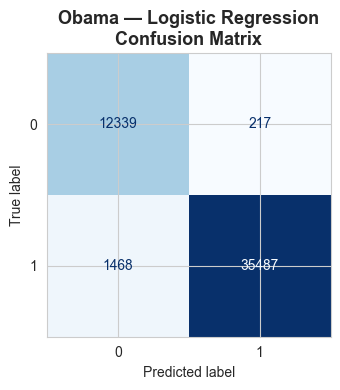

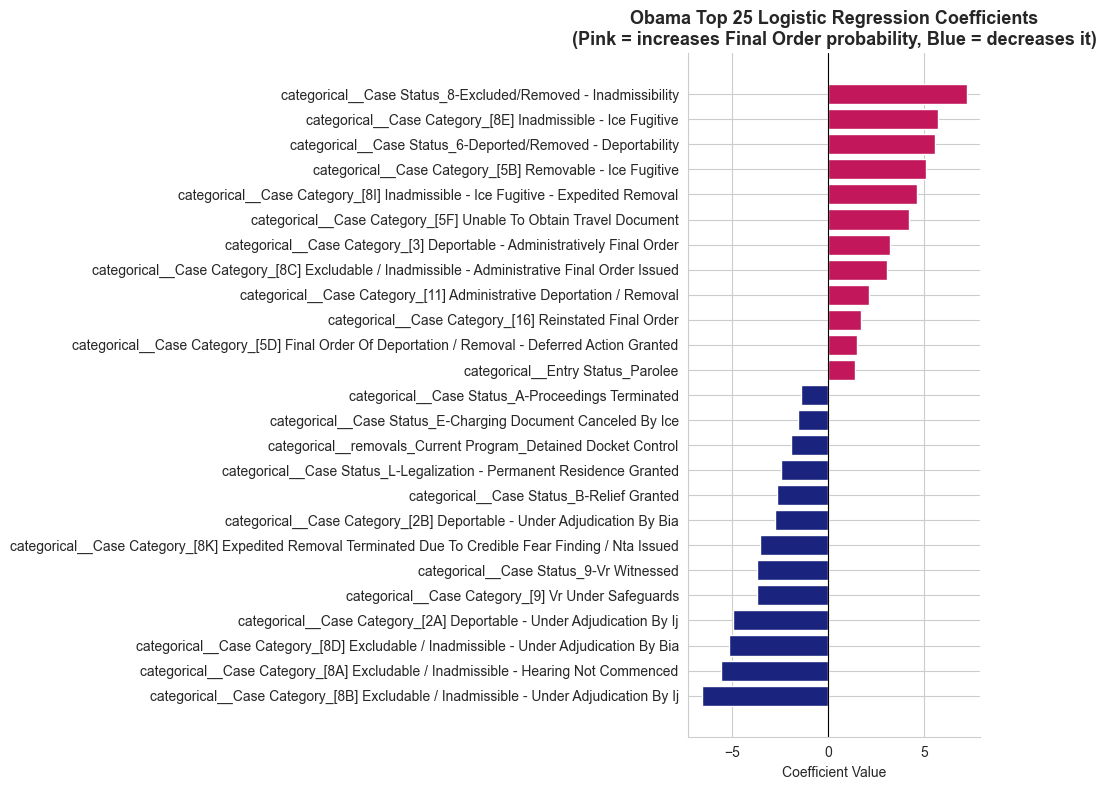

In [11]:
# Obama: Logistic Regression
obama_bin_feats = [f for f in BINARY_FEATURES      if f in obama_df.columns]
obama_num_feats = [f for f in NUMERIC_FEATURES     if f in obama_df.columns]
obama_cat_feats = [f for f in CATEGORICAL_FEATURES if f in obama_df.columns]

lr_ob = build_pipeline(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    obama_bin_feats, obama_num_feats, obama_cat_feats
)
lr_ob.fit(X_train_ob, y_train_ob)

ob_lr_results = evaluate_model(lr_ob, X_test_ob, y_test_ob, 'Logistic Regression', 'Obama')
plot_confusion_matrix(lr_ob, X_test_ob, y_test_ob, 'Logistic Regression', 'Obama', BLUE)

# Get feature names + coefficients
feature_names = lr_ob.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_ob.named_steps['classifier'].coef_[0]

# Build dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Top 25 by importance
coef_df['abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False).head(25)

# Color
coef_df['Color'] = coef_df['Coefficient'].apply(lambda x: PINK if x > 0 else BLUE)

# Sort for plotting
coef_df = coef_df.sort_values('Coefficient')

# Your original plot
plt.figure(figsize=(10, 8))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=coef_df['Color'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Obama Top 25 Logistic Regression Coefficients\n(Pink = increases Final Order probability, Blue = decreases it)')
plt.xlabel('Coefficient Value')
sns.despine()
plt.tight_layout()
plt.show()


  Obama | Decision Tree
  Accuracy : 0.9634
  F1       : 0.9750
  ROC-AUC  : 0.9839
  Avg Prec : 0.9918
              precision    recall  f1-score   support

           0       0.88      0.99      0.93     12556
           1       0.99      0.96      0.97     36955

    accuracy                           0.96     49511
   macro avg       0.94      0.97      0.95     49511
weighted avg       0.97      0.96      0.96     49511



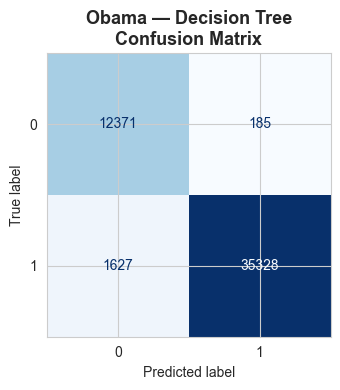

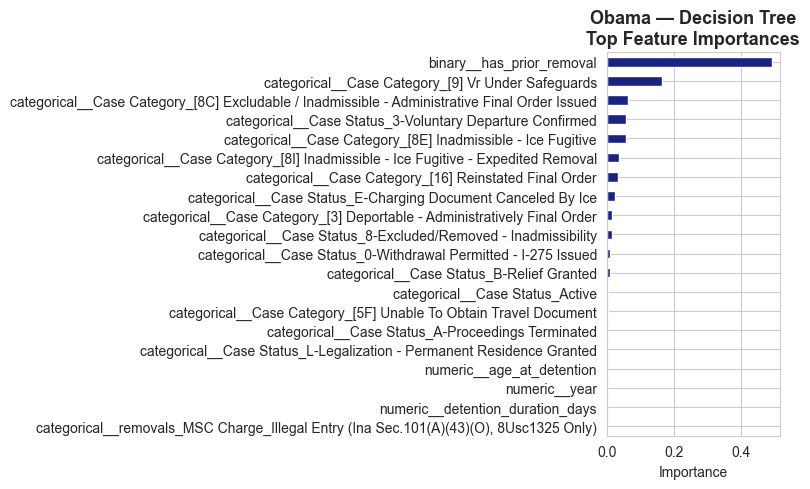


Top 10 features:
                                                                                      Feature  Importance
                                                                    binary__has_prior_removal    0.492823
                                           categorical__Case Category_[9] Vr Under Safeguards    0.164711
categorical__Case Category_[8C] Excludable / Inadmissible - Administrative Final Order Issued    0.062966
                                     categorical__Case Status_3-Voluntary Departure Confirmed    0.057808
                                  categorical__Case Category_[8E] Inadmissible - Ice Fugitive    0.056790
              categorical__Case Category_[8I] Inadmissible - Ice Fugitive - Expedited Removal    0.036467
                                       categorical__Case Category_[16] Reinstated Final Order    0.034211
                                 categorical__Case Status_E-Charging Document Canceled By Ice    0.025028
                     categor

In [12]:
# ── Obama: Decision Tree ───────────────────────────────────────────────────
dt_ob = build_pipeline(
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    obama_bin_feats, obama_num_feats, obama_cat_feats
)
dt_ob.fit(X_train_ob, y_train_ob)

ob_dt_results = evaluate_model(dt_ob, X_test_ob, y_test_ob, 'Decision Tree', 'Obama')
plot_confusion_matrix(dt_ob, X_test_ob, y_test_ob, 'Decision Tree', 'Obama', BLUE)

imp = get_feature_importances(dt_ob)
if imp is not None:
    plot_feature_importances(imp, 'Decision Tree', 'Obama', BLUE)


  Obama | Random Forest
  Accuracy : 0.8948
  F1       : 0.9252
  ROC-AUC  : 0.9842
  Avg Prec : 0.9947
              precision    recall  f1-score   support

           0       0.72      0.97      0.82     12556
           1       0.99      0.87      0.93     36955

    accuracy                           0.89     49511
   macro avg       0.85      0.92      0.87     49511
weighted avg       0.92      0.89      0.90     49511



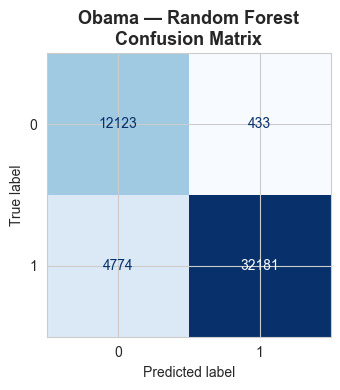

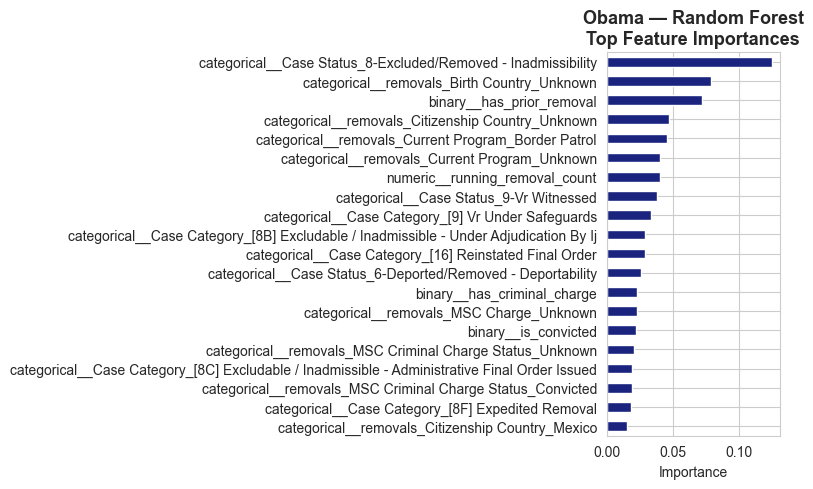


Top 10 features:
                                                                             Feature  Importance
                       categorical__Case Status_8-Excluded/Removed - Inadmissibility    0.125161
                                         categorical__removals_Birth Country_Unknown    0.078836
                                                           binary__has_prior_removal    0.072606
                                   categorical__removals_Citizenship Country_Unknown    0.047265
                                 categorical__removals_Current Program_Border Patrol    0.046101
                                       categorical__removals_Current Program_Unknown    0.040579
                                                      numeric__running_removal_count    0.040345
                                             categorical__Case Status_9-Vr Witnessed    0.037832
                                  categorical__Case Category_[9] Vr Under Safeguards    0.033863
categorical_

In [13]:
# ── Obama: Random Forest ───────────────────────────────────────────────────
rf_ob = build_pipeline(
    RandomForestClassifier(
        n_estimators=200, max_depth=12,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    obama_bin_feats, obama_num_feats, obama_cat_feats
)
rf_ob.fit(X_train_ob, y_train_ob)

ob_rf_results = evaluate_model(rf_ob, X_test_ob, y_test_ob, 'Random Forest', 'Obama')
plot_confusion_matrix(rf_ob, X_test_ob, y_test_ob, 'Random Forest', 'Obama', BLUE)

imp = get_feature_importances(rf_ob)
if imp is not None:
    plot_feature_importances(imp, 'Random Forest', 'Obama', BLUE)

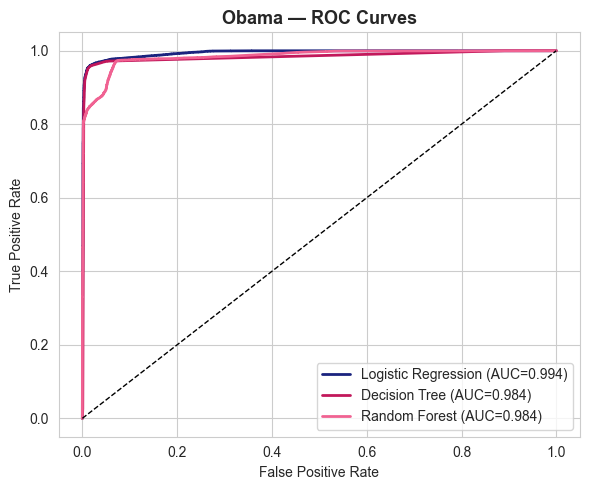

In [14]:
# ── Obama: ROC Curve Comparison ────────────────────────────────────────────
obama_pipelines = {
    'Logistic Regression': lr_ob,
    'Decision Tree':       dt_ob,
    'Random Forest':       rf_ob,
}
plot_roc_curves(obama_pipelines, X_test_ob, y_test_ob, 'Obama')


Obama Fairness Report (Random Forest):


,administration,model,attribute,metric,Hispanic=1,Hispanic=0,gap (1 - 0),Male=1,Male=0,Asylum Seeker=1,Asylum Seeker=0,Criminal Charge=1,Criminal Charge=0,Juvenile=1,Juvenile=0,Border Arrest=1,Border Arrest=0
0,Obama,Random Forest,Hispanic,PPR,0.7552,0.6057,0.1495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Obama,Random Forest,Hispanic,TPR,0.9282,0.8360,0.0922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Obama,Random Forest,Hispanic,FPR,0.0809,0.0159,0.0650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Obama,Random Forest,Hispanic,FNR,0.0718,0.1640,-0.0922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Obama,Random Forest,Hispanic,Precision,0.9781,0.9926,-0.0145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Obama,Random Forest,Male,PPR,NaN,NaN,0.4364,0.7351,0.2987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Obama,Random Forest,Male,TPR,NaN,NaN,0.3492,0.9134,0.5642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Obama,Random Forest,Male,FPR,NaN,NaN,0.0354,0.0462,0.0108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Obama,Random Forest,Male,FNR,NaN,NaN,-0.3492,0.0866,0.4358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Obama,Random Forest,Male,Precision,NaN,NaN,0.0045,0.9871,0.9826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


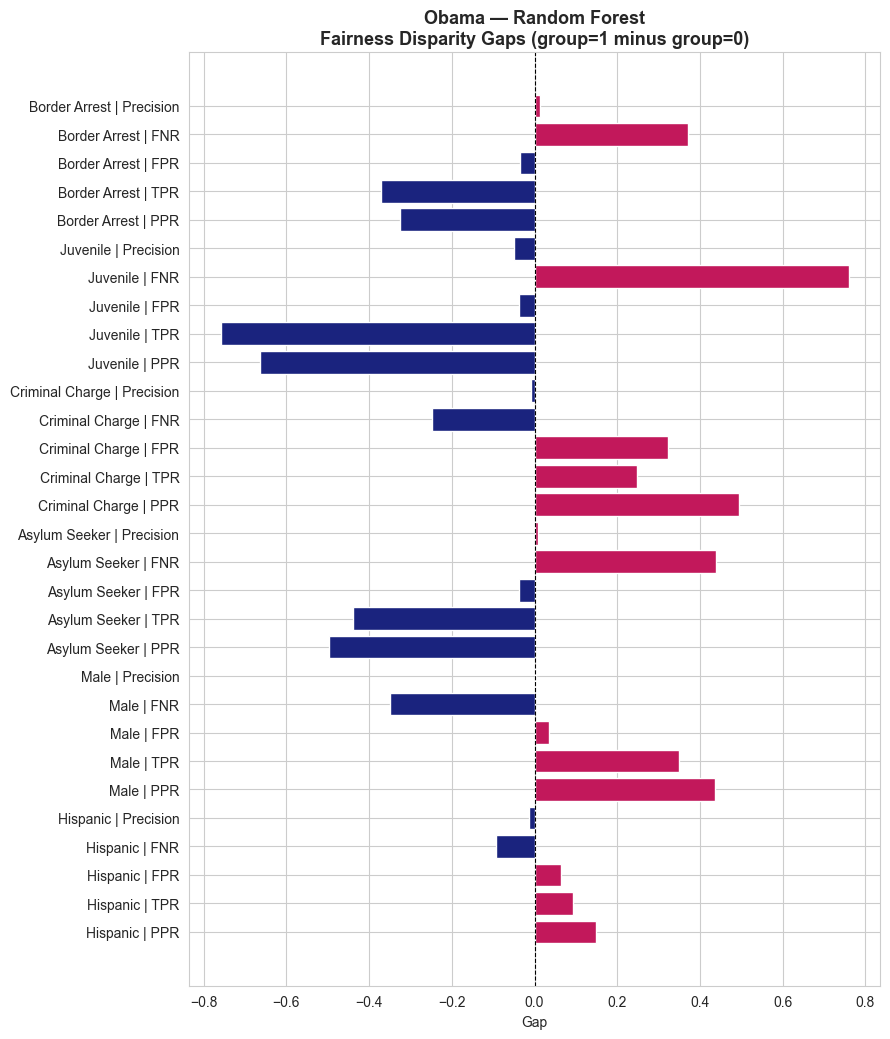

In [15]:
# ── Obama: Fairness Analysis (best model = Random Forest) ──────────────────
obama_fairness_df = fairness_report(
    rf_ob, X_test_ob, y_test_ob,
    SENSITIVE_COLS, admin_name='Obama', model_name='Random Forest'
)

print("\nObama Fairness Report (Random Forest):")
display(obama_fairness_df)
plot_fairness_gaps(obama_fairness_df, 'Obama', 'Random Forest', BLUE)

### Trump Model
---
Model performance remained similarly high under the Trump administration:
- Accuracy ≈ 0.96
- ROC-AUC ≈ 0.99

Despite similar predictive performance, the distribution of outcomes differs from the Obama administration, suggesting changes in enforcement patterns or policy context.

The same core predictors (criminal history, detention, case characteristics) remain important.

In [16]:
# ── Trump: Data Preparation ────────────────────────────────────────────────
trump_features = [f for f in ALL_FEATURES if f in trump_df.columns]

X_trump = trump_df[trump_features]
y_trump = trump_df[TARGET]

valid_mask = y_trump.notna()
X_trump, y_trump = X_trump[valid_mask], y_trump[valid_mask]

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    X_trump, y_trump, test_size=0.2, random_state=42, stratify=y_trump
)

sample_weights_tr = compute_sample_weight('balanced', y_train_tr)

print(f"Trump — Train: {X_train_tr.shape}, Test: {X_test_tr.shape}")
print(f"Target distribution:\n{y_trump.value_counts(normalize=True).round(3)}")

Trump — Train: (241792, 35), Test: (60449, 35)
Target distribution:
final_order_numeric
1    0.616
0    0.384
Name: proportion, dtype: float64



  Trump | Logistic Regression
  Accuracy : 0.9619
  F1       : 0.9685
  ROC-AUC  : 0.9950
  Avg Prec : 0.9971
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     23220
           1       0.98      0.95      0.97     37229

    accuracy                           0.96     60449
   macro avg       0.96      0.96      0.96     60449
weighted avg       0.96      0.96      0.96     60449



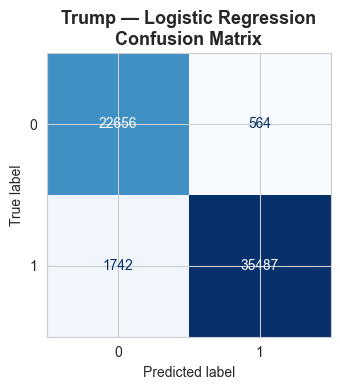

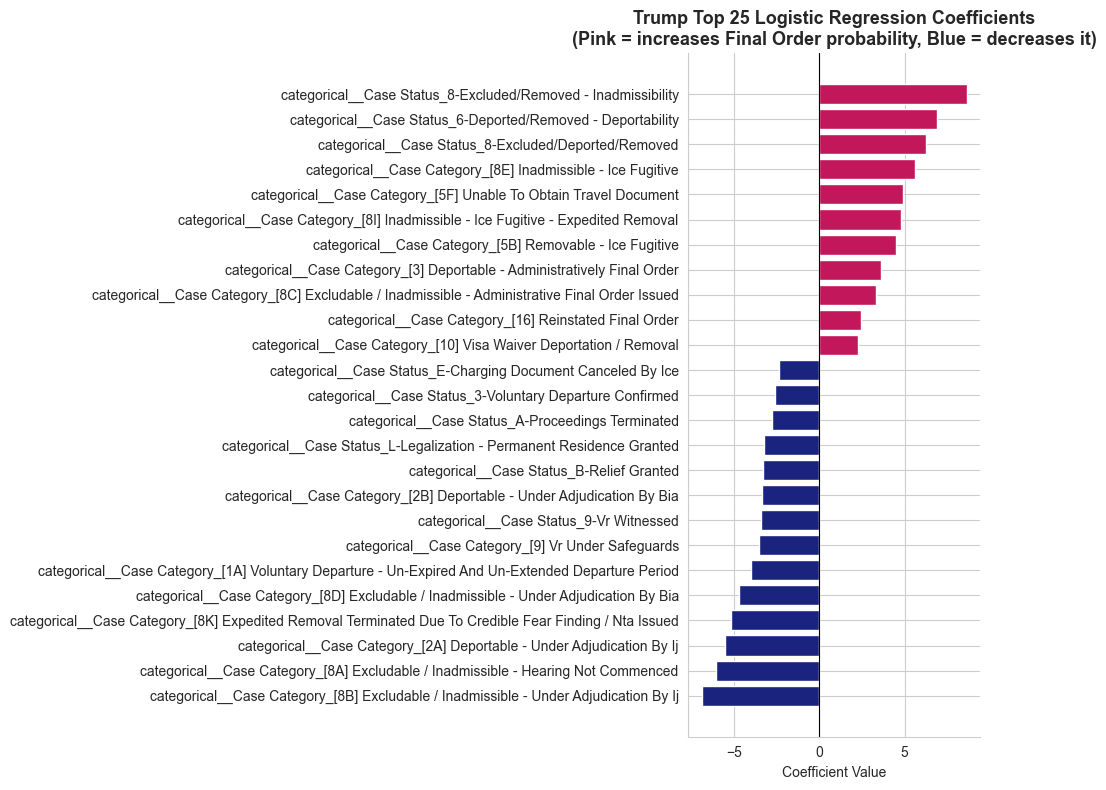

In [17]:
# ── Trump: Logistic Regression ─────────────────────────────────────────────
trump_bin_feats = [f for f in BINARY_FEATURES      if f in trump_df.columns]
trump_num_feats = [f for f in NUMERIC_FEATURES     if f in trump_df.columns]
trump_cat_feats = [f for f in CATEGORICAL_FEATURES if f in trump_df.columns]

lr_tr = build_pipeline(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    trump_bin_feats, trump_num_feats, trump_cat_feats
)
lr_tr.fit(X_train_tr, y_train_tr)

tr_lr_results = evaluate_model(lr_tr, X_test_tr, y_test_tr, 'Logistic Regression', 'Trump')
plot_confusion_matrix(lr_tr, X_test_tr, y_test_tr, 'Logistic Regression', 'Trump', PINK)

# Get feature names + coefficients
feature_names = lr_tr.named_steps['preprocessor'].get_feature_names_out()
coefficients = lr_tr.named_steps['classifier'].coef_[0]

# Build dataframe
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Top 25 by importance
coef_df['abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False).head(25)

# Color
coef_df['Color'] = coef_df['Coefficient'].apply(lambda x: PINK if x > 0 else BLUE)

# Sort for plotting
coef_df = coef_df.sort_values('Coefficient')

# Your original plot
plt.figure(figsize=(10, 8))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=coef_df['Color'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Trump Top 25 Logistic Regression Coefficients\n(Pink = increases Final Order probability, Blue = decreases it)')
plt.xlabel('Coefficient Value')
sns.despine()
plt.tight_layout()
plt.show()


  Trump | Decision Tree
  Accuracy : 0.9597
  F1       : 0.9667
  ROC-AUC  : 0.9840
  Avg Prec : 0.9886
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     23220
           1       0.98      0.95      0.97     37229

    accuracy                           0.96     60449
   macro avg       0.95      0.96      0.96     60449
weighted avg       0.96      0.96      0.96     60449



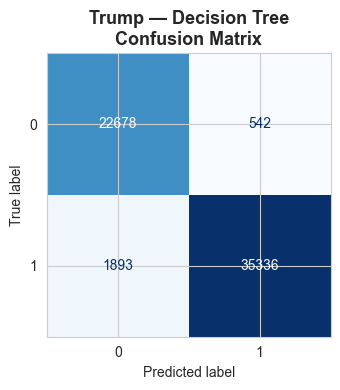

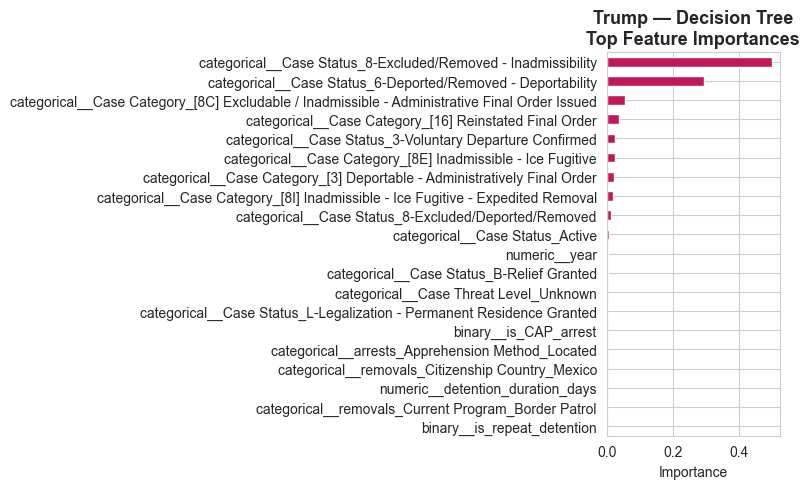


Top 10 features:
                                                                                      Feature  Importance
                                categorical__Case Status_8-Excluded/Removed - Inadmissibility    0.497410
                                  categorical__Case Status_6-Deported/Removed - Deportability    0.293340
categorical__Case Category_[8C] Excludable / Inadmissible - Administrative Final Order Issued    0.054232
                                       categorical__Case Category_[16] Reinstated Final Order    0.037414
                                     categorical__Case Status_3-Voluntary Departure Confirmed    0.025086
                                  categorical__Case Category_[8E] Inadmissible - Ice Fugitive    0.024689
                     categorical__Case Category_[3] Deportable - Administratively Final Order    0.021160
              categorical__Case Category_[8I] Inadmissible - Ice Fugitive - Expedited Removal    0.018150
                            

In [18]:
# ── Trump: Decision Tree ───────────────────────────────────────────────────
dt_tr = build_pipeline(
    DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    trump_bin_feats, trump_num_feats, trump_cat_feats
)
dt_tr.fit(X_train_tr, y_train_tr)

tr_dt_results = evaluate_model(dt_tr, X_test_tr, y_test_tr, 'Decision Tree', 'Trump')
plot_confusion_matrix(dt_tr, X_test_tr, y_test_tr, 'Decision Tree', 'Trump', PINK)

imp = get_feature_importances(dt_tr)
if imp is not None:
    plot_feature_importances(imp, 'Decision Tree', 'Trump', PINK)


  Trump | Random Forest
  Accuracy : 0.9058
  F1       : 0.9194
  ROC-AUC  : 0.9816
  Avg Prec : 0.9892
              precision    recall  f1-score   support

           0       0.82      0.96      0.89     23220
           1       0.97      0.87      0.92     37229

    accuracy                           0.91     60449
   macro avg       0.90      0.92      0.90     60449
weighted avg       0.92      0.91      0.91     60449



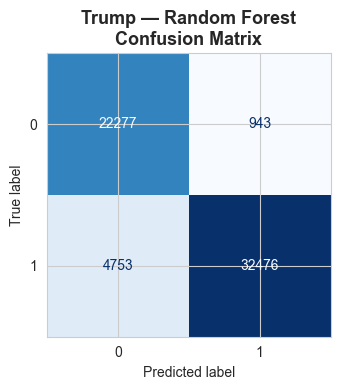

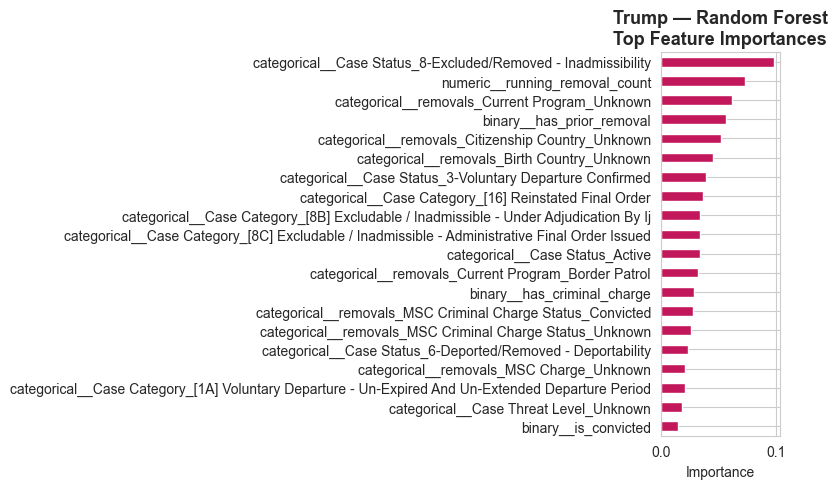


Top 10 features:
                                                                                      Feature  Importance
                                categorical__Case Status_8-Excluded/Removed - Inadmissibility    0.098429
                                                               numeric__running_removal_count    0.072916
                                                categorical__removals_Current Program_Unknown    0.061977
                                                                    binary__has_prior_removal    0.056934
                                            categorical__removals_Citizenship Country_Unknown    0.051816
                                                  categorical__removals_Birth Country_Unknown    0.045334
                                     categorical__Case Status_3-Voluntary Departure Confirmed    0.039527
                                       categorical__Case Category_[16] Reinstated Final Order    0.036446
         categorical__Case C

In [19]:
# ── Trump: Random Forest ───────────────────────────────────────────────────
rf_tr = build_pipeline(
    RandomForestClassifier(
        n_estimators=200, max_depth=12,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    trump_bin_feats, trump_num_feats, trump_cat_feats
)
rf_tr.fit(X_train_tr, y_train_tr)

tr_rf_results = evaluate_model(rf_tr, X_test_tr, y_test_tr, 'Random Forest', 'Trump')
plot_confusion_matrix(rf_tr, X_test_tr, y_test_tr, 'Random Forest', 'Trump', PINK)

imp = get_feature_importances(rf_tr)
if imp is not None:
    plot_feature_importances(imp, 'Random Forest', 'Trump', PINK)

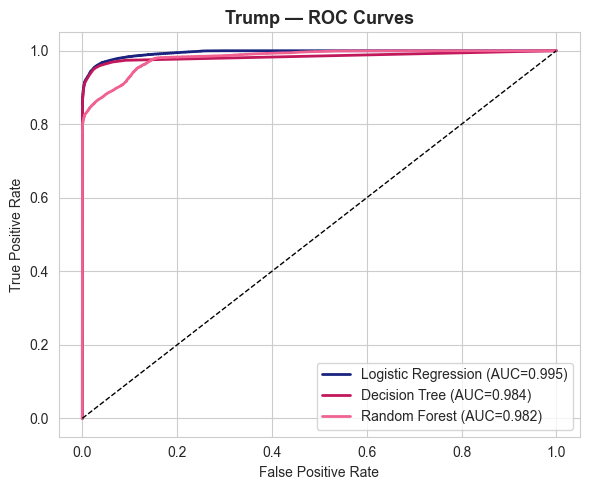

In [20]:
# ── Trump: ROC Curve Comparison ────────────────────────────────────────────
trump_pipelines = {
    'Logistic Regression': lr_tr,
    'Decision Tree':       dt_tr,
    'Random Forest':       rf_tr,
}
plot_roc_curves(trump_pipelines, X_test_tr, y_test_tr, 'Trump')


Trump Fairness Report (Random Forest):


,administration,model,attribute,metric,Hispanic=1,Hispanic=0,gap (1 - 0),Male=1,Male=0,Asylum Seeker=1,Asylum Seeker=0,Criminal Charge=1,Criminal Charge=0,Juvenile=1,Juvenile=0,Border Arrest=1,Border Arrest=0
0,Trump,Random Forest,Hispanic,PPR,0.6031,0.5114,0.0918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Trump,Random Forest,Hispanic,TPR,0.9010,0.8465,0.0545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Trump,Random Forest,Hispanic,FPR,0.0620,0.0252,0.0368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trump,Random Forest,Hispanic,FNR,0.0990,0.1535,-0.0545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Trump,Random Forest,Hispanic,Precision,0.9635,0.9799,-0.0164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Trump,Random Forest,Male,PPR,NaN,NaN,0.2899,0.6003,0.3104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Trump,Random Forest,Male,TPR,NaN,NaN,0.1734,0.8917,0.7183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Trump,Random Forest,Male,FPR,NaN,NaN,0.0345,0.0491,0.0147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Trump,Random Forest,Male,FNR,NaN,NaN,-0.1734,0.1083,0.2817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Trump,Random Forest,Male,Precision,NaN,NaN,-0.0009,0.9717,0.9726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


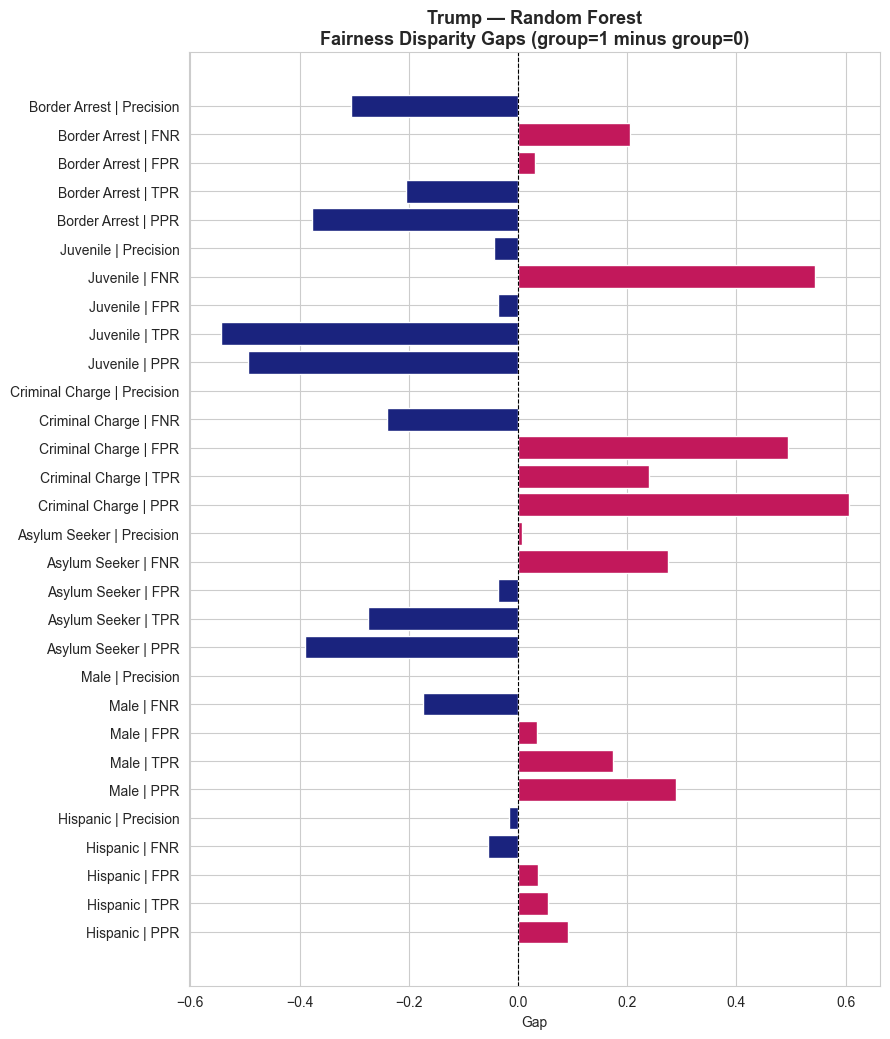

In [21]:
# ── Trump: Fairness Analysis (best model = Random Forest) ──────────────────
trump_fairness_df = fairness_report(
    rf_tr, X_test_tr, y_test_tr,
    SENSITIVE_COLS, admin_name='Trump', model_name='Random Forest'
)

print("\nTrump Fairness Report (Random Forest):")
display(trump_fairness_df)
plot_fairness_gaps(trump_fairness_df, 'Trump', 'Random Forest', PINK)

### Cross-Administration Comparison
---
Comparing models across administrations shows that:
- Predictive performance is consistently high across both periods
- Logistic Regression performs best overall, suggesting stable linear relationships
- Random Forest shows slightly lower accuracy but remains useful for interpretability

This indicates that while policies may change outcome rates, the underlying predictive structure remains similar.

In [22]:
# Performance Comparison Table
all_results = [
    ob_lr_results, ob_dt_results, ob_rf_results,
    tr_lr_results, tr_dt_results, tr_rf_results,
]
perf_df = pd.DataFrame(all_results).set_index(['administration', 'model'])
print("\nPerformance Comparison:")
display(perf_df.round(4))


Performance Comparison:


accuracy      f1  roc_auc  avg_precision
administration model                                                        
Obama          Logistic Regression    0.9660  0.9768   0.9942         0.9978
               Decision Tree          0.9634  0.9750   0.9839         0.9918
               Random Forest          0.8948  0.9252   0.9842         0.9947
Trump          Logistic Regression    0.9619  0.9685   0.9950         0.9971
               Decision Tree          0.9597  0.9667   0.9840         0.9886
               Random Forest          0.9058  0.9194   0.9816         0.9892

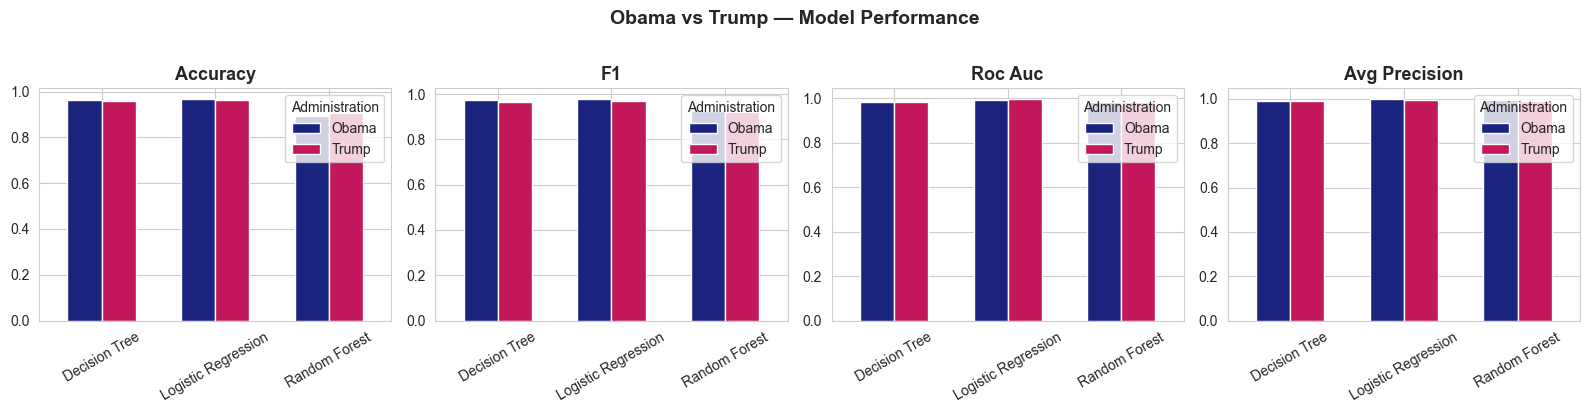

In [23]:
# Performance Bar Chart
metrics = ['accuracy', 'f1', 'roc_auc', 'avg_precision']
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4), sharey=False)

for ax, metric in zip(axes, metrics):
    pivot = perf_df[metric].unstack(level=0)  # columns = administrations
    pivot.plot(kind='bar', ax=ax, color=[BLUE, PINK], edgecolor='white', width=0.6)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Administration')

fig.suptitle("Obama vs Trump — Model Performance", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Fairness Analysis
We evaluated fairness across several sensitive attributes, including:
- Hispanic vs. non-Hispanic
- Male vs. female
- Juvenile vs. adult
- Asylum seeker status

We measured disparities using metrics such as:
- Positive Prediction Rate (PPR)
- True Positive Rate (TPR)
- False Positive Rate (FPR)

Results show significant disparities across multiple groups. For example:
- Hispanic individuals have higher predicted rates of Final Orders
- Males have substantially higher prediction rates than females
- Juveniles are significantly less likely to receive predicted Final Orders

These disparities persist across both administrations.

In [24]:
# Fairness Disparity Comparison (Random Forest)
combined_fairness = pd.concat([obama_fairness_df, trump_fairness_df], ignore_index=True)

print("\nCombined Fairness Gaps (Random Forest):")
display(
    combined_fairness[['administration', 'attribute', 'metric', 'gap (1 - 0)']]
    .pivot_table(index=['attribute', 'metric'], columns='administration', values='gap (1 - 0)')
    .round(4)
)


Combined Fairness Gaps (Random Forest):


administration              Obama   Trump
attribute       metric                   
Asylum Seeker   FNR        0.4392  0.2742
                FPR       -0.0373 -0.0373
                PPR       -0.4960 -0.3905
                Precision  0.0091  0.0074
                TPR       -0.4392 -0.2742
Border Arrest   FNR        0.3708  0.2057
                FPR       -0.0345  0.0308
                PPR       -0.3254 -0.3765
                Precision  0.0133 -0.3051
                TPR       -0.3708 -0.2057
Criminal Charge FNR       -0.2473 -0.2405
                FPR        0.3229  0.4948
                PPR        0.4944  0.6056
                Precision -0.0074 -0.0018
                TPR        0.2473  0.2405
Hispanic        FNR       -0.0922 -0.0545
                FPR        0.0650  0.0368
                PPR        0.1495  0.0918
                Precision -0.0145 -0.0164
                TPR        0.0922  0.0545
Juvenile        FNR        0.7593  0.5448
                FPR       -0.0383 -0.0367
                PPR       -0.6647 -0.4952
                Precision -0.0492 -0.0445
                TPR       -0.7593 -0.5448
Male            FNR       -0.3492 -0.1734
                FPR        0.0354  0.0345
                PPR        0.4364  0.2899
                Precision  0.0045 -0.0009
                TPR        0.3492  0.1734

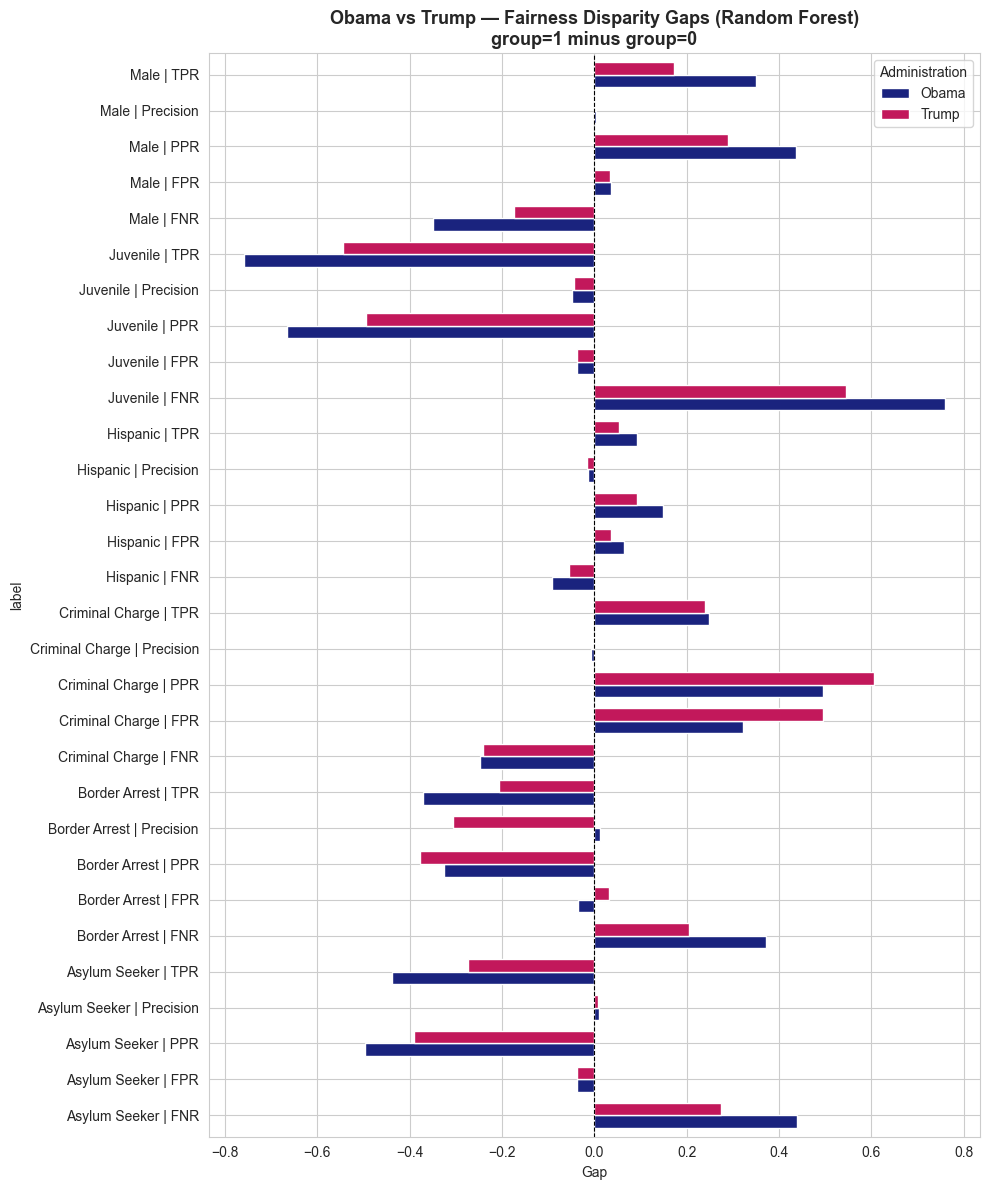

In [25]:
# Side-by-Side Fairness Gap Plot
pivot_fair = (
    combined_fairness
    .assign(label=lambda d: d['attribute'] + ' | ' + d['metric'])
    .pivot_table(index='label', columns='administration', values='gap (1 - 0)')
)

fig, ax = plt.subplots(figsize=(10, max(5, len(pivot_fair) * 0.4)))
pivot_fair.plot(kind='barh', ax=ax, color=[BLUE, PINK], edgecolor='white', width=0.7)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_title("Obama vs Trump — Fairness Disparity Gaps (Random Forest)\ngroup=1 minus group=0",
             fontweight='bold')
ax.set_xlabel("Gap")
ax.legend(title='Administration')
plt.tight_layout()
plt.show()

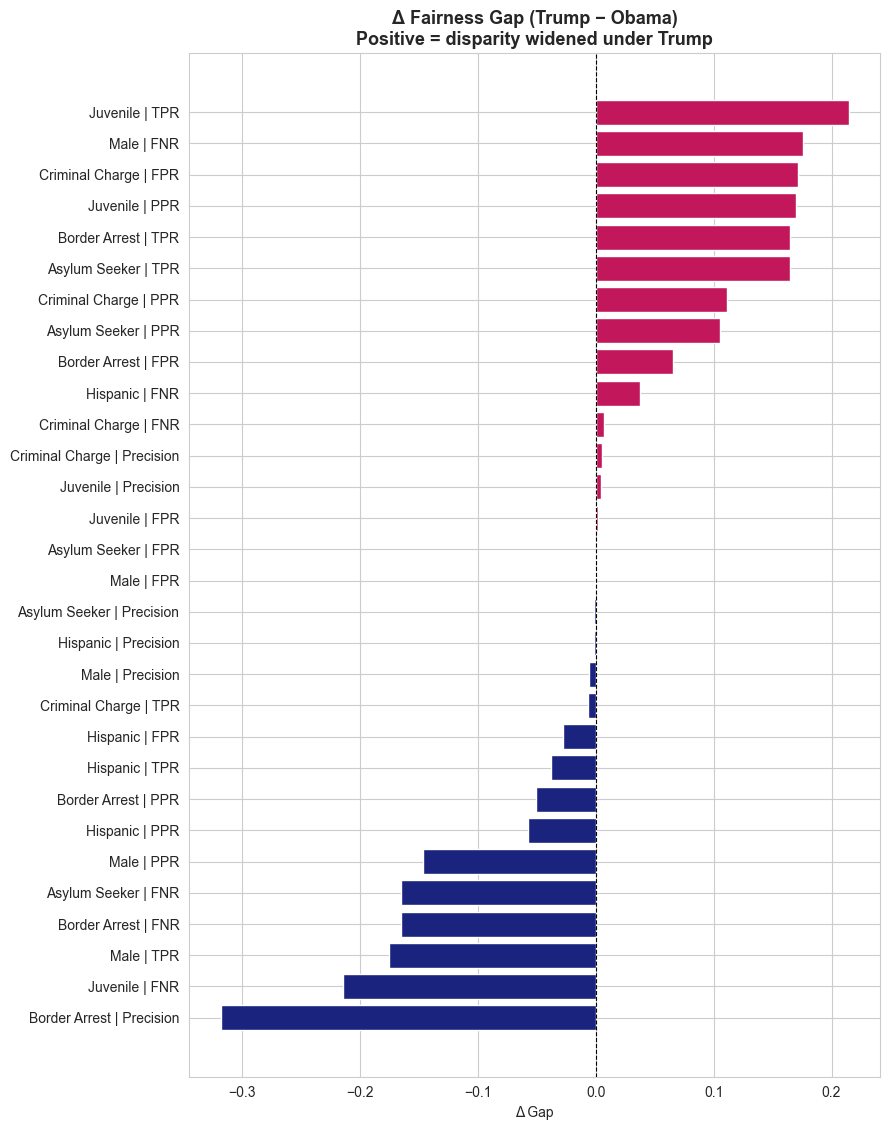


Largest increases in disparity (Trump vs Obama):


,label,Δ gap
0,Border Arrest | TPR,0.1651
1,Juvenile | PPR,0.1695
2,Criminal Charge | FPR,0.1719
3,Male | FNR,0.1758
4,Juvenile | TPR,0.2145



Largest decreases in disparity (Trump vs Obama):


,label,Δ gap
0,Border Arrest | Precision,-0.3184
1,Juvenile | FNR,-0.2145
2,Male | TPR,-0.1758
3,Border Arrest | FNR,-0.1651
4,Asylum Seeker | FNR,-0.1650


In [26]:
# ── Δ Gap: How much did fairness disparities shift between administrations? ─
delta = pivot_fair['Trump'] - pivot_fair['Obama']
delta = delta.sort_values()

fig, ax = plt.subplots(figsize=(9, max(4, len(delta) * 0.38)))
colors = [PINK if v > 0 else BLUE for v in delta]
ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_title("Δ Fairness Gap (Trump − Obama)\nPositive = disparity widened under Trump",
             fontweight='bold')
ax.set_xlabel("Δ Gap")
plt.tight_layout()
plt.show()

print("\nLargest increases in disparity (Trump vs Obama):")
display(delta.tail(5).reset_index().rename(columns={0: 'Δ gap'}))

print("\nLargest decreases in disparity (Trump vs Obama):")
display(delta.head(5).reset_index().rename(columns={0: 'Δ gap'}))

#### Feature Importance Comparisons
Obama model
- has_prior_removal dominates (~0.49 importance)
- Case categories matter, but less dominant
- More individual history-driven

Trump model
- Case Status features dominate (~0.49 + 0.29)
- has_prior_removal is still important but less dominant
- More system/process-driven

In [27]:
def compare_feature_importances(imp_obama, imp_trump, top_n=15):
    """
    Combines and compares feature importances from two administrations.
    """
    # Normalize (optional but recommended for fair comparison)
    imp_obama = imp_obama / imp_obama.sum()
    imp_trump = imp_trump / imp_trump.sum()

    # Combine
    df_compare = pd.concat([
        imp_obama.rename('Obama'),
        imp_trump.rename('Trump')
    ], axis=1).fillna(0)

    # Get top features overall
    df_compare['avg'] = df_compare.mean(axis=1)
    df_compare = df_compare.sort_values('avg', ascending=False).head(top_n)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    df_compare[['Obama', 'Trump']].sort_values('Obama').plot(
        kind='barh',
        ax=ax
    )

    ax.set_title("Top Feature Importance Comparison: Obama vs Trump")
    ax.set_xlabel("Normalized Importance")
    ax.legend(title="Administration")
    plt.tight_layout()
    plt.show()

    return df_compare

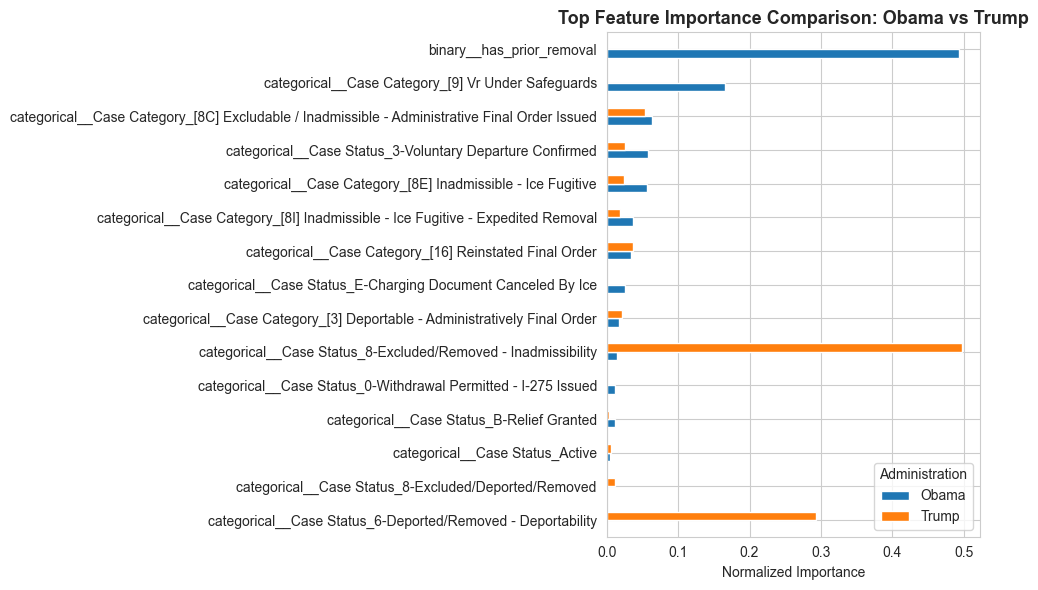

,Obama,Trump,avg
categorical__Case Status_8-Excluded/Removed - Inadmissibility,0.014759,0.497623,0.256191
binary__has_prior_removal,0.493766,0.000000,0.246883
categorical__Case Status_6-Deported/Removed - Deportability,0.000000,0.293465,0.146733
categorical__Case Category_[9] Vr Under Safeguards,0.165026,0.000000,0.082513
categorical__Case Category_[8C] Excludable / Inadmissible - Administrative Final Order Issued,0.063086,0.054255,0.058671
categorical__Case Status_3-Voluntary Departure Confirmed,0.057919,0.025097,0.041508
categorical__Case Category_[8E] Inadmissible - Ice Fugitive,0.056899,0.024699,0.040799
categorical__Case Category_[16] Reinstated Final Order,0.034276,0.037430,0.035853
categorical__Case Category_[8I] Inadmissible - Ice Fugitive - Expedited Removal,0.036537,0.018157,0.027347
categorical__Case Category_[3] Deportable - Administratively Final Order,0.017257,0.021169,0.019213


In [28]:
# Decision Tree comparison
imp_ob_dt = get_feature_importances(dt_ob)
imp_tr_dt = get_feature_importances(dt_tr)

compare_feature_importances(imp_ob_dt, imp_tr_dt)

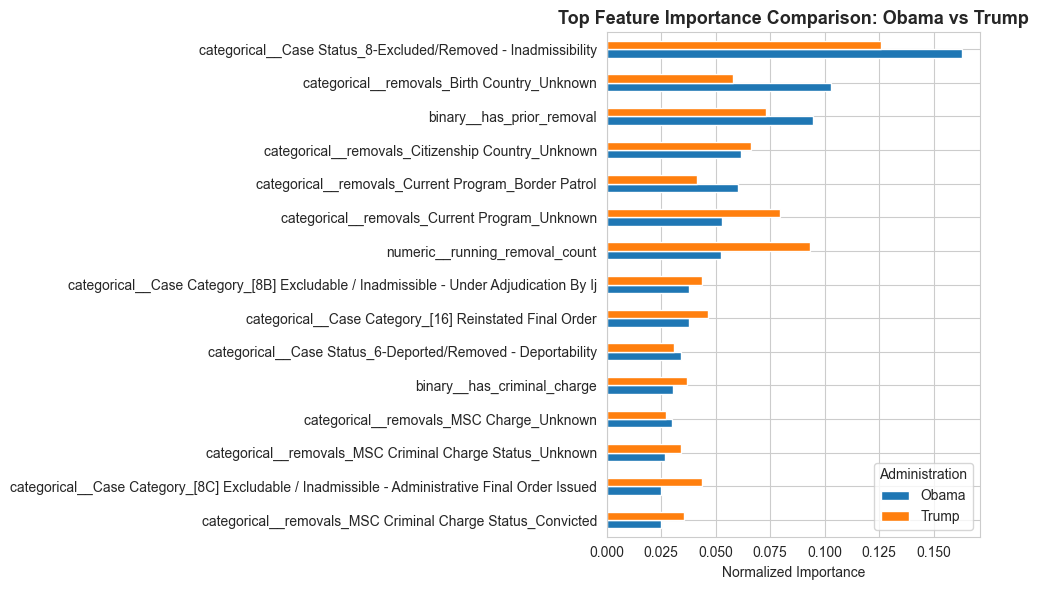

,Obama,Trump,avg
categorical__Case Status_8-Excluded/Removed - Inadmissibility,0.163058,0.126034,0.144546
binary__has_prior_removal,0.094590,0.072902,0.083746
categorical__removals_Birth Country_Unknown,0.102706,0.058049,0.080378
numeric__running_removal_count,0.052561,0.093366,0.072963
categorical__removals_Current Program_Unknown,0.052866,0.079359,0.066112
categorical__removals_Citizenship Country_Unknown,0.061576,0.066348,0.063962
categorical__removals_Current Program_Border Patrol,0.060060,0.041397,0.050729
categorical__Case Category_[16] Reinstated Final Order,0.037575,0.046668,0.042121
categorical__Case Category_[8B] Excludable / Inadmissible - Under Adjudication By Ij,0.037683,0.043813,0.040748
categorical__Case Category_[8C] Excludable / Inadmissible - Administrative Final Order Issued,0.025110,0.043562,0.034336


In [29]:
# Random Forest comparison
imp_ob_rf = get_feature_importances(rf_ob)
imp_tr_rf = get_feature_importances(rf_tr)

compare_feature_importances(imp_ob_rf, imp_tr_rf)

Comparing feature importances across the Obama and Trump administration models reveals a meaningful shift in what drives deportation outcomes.

Under the Obama administration, the most influential predictor is prior removal history, which accounts for nearly half of the decision tree’s importance. This suggests that enforcement decisions were strongly influenced by an individual’s past immigration history. In other words, repeat interactions with the system played a central role in determining outcomes.

In contrast, under the Trump administration, case status variables dominate the model, with features such as “Excluded/Removed – Inadmissibility” and “Deported/Removed – Deportability” contributing the majority of predictive power. This indicates that deportation outcomes became more directly tied to the current legal classification and procedural status of a case, rather than prior history alone.

This shift suggests a change in enforcement emphasis:

- Obama administration: more weight on individual history and prior offenses
- Trump administration: more weight on case processing categories and legal status

Despite this difference, some predictors remain consistently important across both administrations:

- Prior removal history
- Case category
- Removal-related variables

This consistency helps explain why overall model performance remains high and stable, even though the underlying decision logic shifts.

### Research Question Analysis
---
#### To what extent can deportation outcomes be predicted… and how do predictors differ between administrations?
Deportation outcomes (Final Order vs. not) can be predicted very accurately using political, demographic, and situational variables. Across both administrations, models achieved very high performance (ROC-AUC ≈ 0.98–0.995; Accuracy ≈ 0.89-0.97), indicating strong predictive signal in the data.

The best-performing model overall was Logistic Regression, achieving:
- Obama: AUC = 0.994
- Trump: AUC = 0.995

This suggests that relationships between features and deportation outcomes are largely linear and consistent, rather than requiring complex models.

**Across administrations:**

Predictive performance is very similar
BUT the distribution of outcomes differs:
- Obama: ~75% Final Orders
- Trump: ~62% Final Orders

This indicates that while prediction is stable, underlying policy/context likely changed outcome rates.